# 02 - Event Data Collection

## Goal

The goal of this notebook is to collect detailed event-level data for all matches in the FA Women's Super League (2023/2024) using the StatsBomb Open Data API.

The collected event data will serve as the primary dataset for data preprocessing, feature engineering, exploratory analysis and predictive modeling in subsequent notebooks.

## Import Libraries

In [87]:
from statsbombpy import sb
import pandas as pd
import matplotlib.pyplot as plt

## Load Match Data

In [88]:
matches = sb.matches(
    competition_id=37,
    season_id=281
)

matches.head()

c:\Users\Korisnik\Desktop\Women's Football Analytics\.venv\Lib\site-packages\statsbombpy\api_client.py:23: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


,match_id,match_date,kick_off,home_score,away_score,match_status,match_status_360,last_updated,last_updated_360,match_week,...,home_manager_country_name,away_manager_id,away_manager_name,away_manager_nickname,away_manager_dob,away_manager_country_id,away_manager_country_name,data_version,shot_fidelity_version,xy_fidelity_version
0,3913082,2023-11-05,18:45:00.000,2,2,available,unscheduled,2026-04-11T13:03:17.779673,None,5,...,England,128,Marc Skinner,None,1983-03-23,68,England,1.1.0,2,2
1,3913155,2024-03-23,12:30:00.000,3,1,available,unscheduled,2026-04-11T13:01:12.427016,None,17,...,Wales,128,Marc Skinner,None,1983-03-23,68,England,1.1.0,2,2
2,3913167,2024-04-21,11:00:00.000,2,2,available,unscheduled,2026-04-10T15:02:10.119805,None,19,...,England,1000768,Robert Vilahamn,None,1983-01-02,220,Sweden,1.1.0,2,2
3,3913175,2024-04-28,13:00:00.000,1,1,available,unscheduled,2026-04-07T09:17:31.343400,None,20,...,England,5389,Rehanne Skinner,None,1979-11-13,68,England,1.1.0,2,2
4,3913107,2023-12-09,12:00:00.000,2,1,available,unscheduled,2026-04-07T09:17:06.305626,None,9,...,Wales,3978,Carla Ward,None,1982-12-21,68,England,1.1.0,2,2


## Explore a Sample Match

In [89]:
matches[["match_id","home_team","away_team"]].head()

,match_id,home_team,away_team
0,3913082,Brighton & Hove Albion WFC,Manchester United W
1,3913155,Manchester City WFC,Manchester United W
2,3913167,Manchester United W,Tottenham Hotspur Women
3,3913175,Aston Villa W,West Ham United LFC
4,3913107,Manchester City WFC,Aston Villa W


In [90]:
first_match = matches.iloc[0]["match_id"]

first_match

np.int64(3913082)

## Collect Event Data

In [91]:
sample_events = sb.events(match_id=first_match)

c:\Users\Korisnik\Desktop\Women's Football Analytics\.venv\Lib\site-packages\statsbombpy\api_client.py:23: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


In [92]:
sample_events.shape

(3309, 94)

In [93]:
sample_events.head()

,50_50,bad_behaviour_card,ball_receipt_outcome,ball_recovery_offensive,ball_recovery_recovery_failure,block_offensive,carry_end_location,clearance_aerial_won,clearance_body_part,clearance_head,...,substitution_outcome,substitution_outcome_id,substitution_replacement,substitution_replacement_id,tactics,team,team_id,timestamp,type,under_pressure
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,"{'formation': 343, 'lineup': [{'player': {'id'...",Brighton & Hove Albion WFC,965,00:00:00.000,Starting XI,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,"{'formation': 433, 'lineup': [{'player': {'id'...",Manchester United W,1475,00:00:00.000,Starting XI,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Brighton & Hove Albion WFC,965,00:00:00.000,Half Start,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Manchester United W,1475,00:00:00.000,Half Start,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Manchester United W,1475,00:00:00.000,Half Start,NaN


In [94]:
sample_events.info()

<class 'pandas.DataFrame'>
RangeIndex: 3309 entries, 0 to 3308
Data columns (total 94 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   50_50                           9 non-null      object 
 1   bad_behaviour_card              2 non-null      str    
 2   ball_receipt_outcome            188 non-null    str    
 3   ball_recovery_offensive         1 non-null      object 
 4   ball_recovery_recovery_failure  15 non-null     object 
 5   block_offensive                 1 non-null      object 
 6   carry_end_location              691 non-null    object 
 7   clearance_aerial_won            10 non-null     object 
 8   clearance_body_part             58 non-null     str    
 9   clearance_head                  31 non-null     object 
 10  clearance_left_foot             9 non-null      object 
 11  clearance_right_foot            18 non-null     object 
 12  counterpress                    111 non-null 

In [95]:
list(sample_events.columns)

['50_50',
 'bad_behaviour_card',
 'ball_receipt_outcome',
 'ball_recovery_offensive',
 'ball_recovery_recovery_failure',
 'block_offensive',
 'carry_end_location',
 'clearance_aerial_won',
 'clearance_body_part',
 'clearance_head',
 'clearance_left_foot',
 'clearance_right_foot',
 'counterpress',
 'dribble_nutmeg',
 'dribble_outcome',
 'dribble_overrun',
 'duel_outcome',
 'duel_type',
 'duration',
 'foul_committed_advantage',
 'foul_committed_card',
 'foul_committed_type',
 'foul_won_advantage',
 'foul_won_defensive',
 'goalkeeper_body_part',
 'goalkeeper_end_location',
 'goalkeeper_outcome',
 'goalkeeper_position',
 'goalkeeper_shot_saved_to_post',
 'goalkeeper_technique',
 'goalkeeper_type',
 'id',
 'index',
 'injury_stoppage_in_chain',
 'interception_outcome',
 'location',
 'match_id',
 'minute',
 'off_camera',
 'out',
 'pass_aerial_won',
 'pass_angle',
 'pass_assisted_shot_id',
 'pass_body_part',
 'pass_cross',
 'pass_cut_back',
 'pass_deflected',
 'pass_end_location',
 'pass_goal_

In [72]:
all_events = []

In [73]:
for match_id in matches["match_id"]:
    
    match_events = sb.events(match_id=match_id)

    all_events.append(match_events)

c:\Users\Korisnik\Desktop\Women's Football Analytics\.venv\Lib\site-packages\statsbombpy\api_client.py:23: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


## Merge Event Data

In [74]:
events_df = pd.concat(
    all_events,
    ignore_index=True
)

## Explore the Combined Dataset

In [75]:
events_df.shape

(495189, 115)

In [76]:
events_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 495189 entries, 0 to 495188
Columns: 115 entries, 50_50 to goalkeeper_penalty_saved_to_post
dtypes: float64(8), int64(8), object(63), str(36)
memory usage: 434.5+ MB


In [77]:
events_df["type"].value_counts()

type
Pass                 133573
Ball Receipt*        127398
Carry                108472
Pressure              51705
Ball Recovery         15818
Duel                   9090
Block                  6386
Clearance              6040
Miscontrol             4420
Goal Keeper            4315
Dribble                4085
Dispossessed           3726
Shot                   3529
Interception           2994
Foul Committed         2565
Foul Won               2447
Dribbled Past          2422
Substitution           1080
50/50                   965
Injury Stoppage         851
Half Start              528
Half End                528
Referee Ball-Drop       513
Tactical Shift          494
Starting XI             264
Shield                  225
Player Off              223
Player On               221
Error                   137
Bad Behaviour            95
Offside                  46
Own Goal Against         17
Own Goal For             17
Name: count, dtype: int64

The chart below shows the distribution of the most frequent event types recorded during the FA Women's Super League 2023/2024 season.

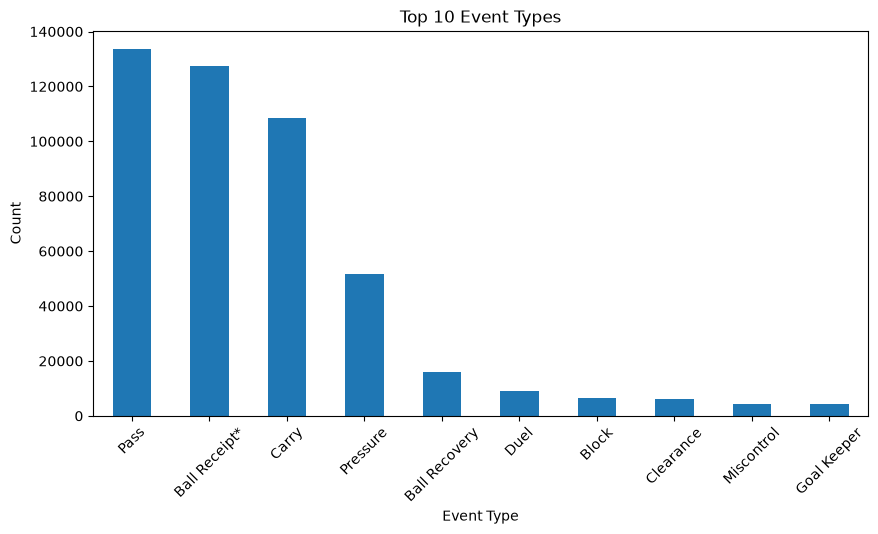

In [78]:
events_df["type"].value_counts().head(10).plot.bar(figsize=(10,5))

plt.title("Top 10 Event Types")
plt.xlabel("Event Type")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

In [79]:
event_summary = pd.DataFrame({
    "Event Type": ["Pass", "Shot", "Dribble"],
    "Count": [
        (events_df["type"] == "Pass").sum(),
        (events_df["type"] == "Shot").sum(),
        (events_df["type"] == "Dribble").sum()
    ]
})

event_summary

,Event Type,Count
0,Pass,133573
1,Shot,3529
2,Dribble,4085


## Save Dataset

In [80]:
events_df.to_csv(
    "../data/raw/fawsl_events.csv",
    index=False
)

## Validate Saved Dataset

In [81]:
import os

os.path.exists("../data/raw/fawsl_events.csv")

True

In [82]:
events_df = pd.read_csv("../data/raw/fawsl_events.csv")

events_df.shape

C:\Users\Korisnik\AppData\Local\Temp\ipykernel_14260\2477118649.py:1: DtypeWarning: Columns (0: bad_behaviour_card, 1: ball_recovery_offensive, 2: block_offensive, 3: dribble_nutmeg, 4: dribble_overrun, 5: foul_committed_advantage, 6: foul_committed_card, 7: foul_committed_type, 8: foul_won_advantage, 9: goalkeeper_shot_saved_to_post, 10: injury_stoppage_in_chain, 11: pass_deflected, 12: pass_straight, 13: shot_one_on_one, 14: shot_open_goal, 15: shot_saved_to_post, 16: block_deflection, 17: miscontrol_aerial_won, 18: pass_outswinging, 19: shot_deflected, 20: goalkeeper_shot_saved_off_target, 21: pass_miscommunication, 22: pass_no_touch, 23: shot_redirect, 24: shot_saved_off_target, 25: clearance_other, 26: foul_committed_offensive, 27: dribble_no_touch, 28: block_save_block, 29: foul_committed_penalty, 30: foul_won_penalty, 31: player_off_permanent, 32: goalkeeper_lost_out, 33: goalkeeper_punched_out, 34: goalkeeper_success_out, 35: goalkeeper_success_in_play, 36: goalkeeper_penalty_s

(495189, 115)

## Dataset Summary

In [83]:
events_df["match_id"].nunique()

132

In [84]:
events_df["player"].nunique()

294

In [85]:
events_df["team"].nunique()

12

In [86]:
round(events_df.memory_usage(deep=True).sum() / 1024**2, 2)

np.float64(1763.0)

## Conclusion

All event-level data for the FA Women's Super League 2023/2024 season has been successfully collected and stored as a local dataset.

This dataset will be used as the primary data source for preprocessing, feature engineering, exploratory analysis, and predictive modeling in the following stages of the project.